<div style="text-align: right;">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/5e/HdM_Logo.svg/100px-HdM_Logo.svg.png"
       alt="HdM Logo"
       width="120">
</div>

### Lineare Regression: Überlegungen zum Grundverständnis (Manhattan)

---

Annette Kufner

---


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [8]:
df = pd.read_csv('../data/processed/airbnb_NYC_model_data.csv')

In [9]:
df.head()


,id,neighbourhood_group_cleansed,room_type,instant_bookable,accommodates,bathrooms,bedrooms,beds,host_total_listings_count,distance_to_center,price,ln_price
0,40824219,Queens,Private room,False,1,1.0,1.0,1.0,3.0,5.846824,66.0,4.204693
1,40839416,Manhattan,Private room,False,1,2.0,1.0,1.0,16.0,4.068795,76.0,4.343805
2,40843980,Queens,Entire home/apt,False,6,1.0,2.0,3.0,2.0,14.496832,97.0,4.584967
3,40824301,Brooklyn,Private room,False,1,1.0,2.0,1.0,1.0,6.134544,60.0,4.110874
4,40825740,Brooklyn,Entire home/apt,False,6,4.0,3.0,3.0,9.0,10.045623,425.0,6.054439


In [10]:
print(df.columns)


Index(['id', 'neighbourhood_group_cleansed', 'room_type', 'instant_bookable',
       'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'host_total_listings_count', 'distance_to_center', 'price', 'ln_price'],
      dtype='object')


In [39]:
# 1. Daten vorbereiten (Filter auf Manhattan & Zeilen ohne NaN in distance_to_center)
df_manhattan = df[df['neighbourhood_group_cleansed'] == 'Manhattan'].dropna(subset=['distance_to_center', 'price'])

# 2. Mittelwerte berechnen (x_quer und y_quer)
x_mean = df_manhattan['distance_to_center'].mean()
y_mean = df_manhattan['price'].mean()

# 3. Lineare Regression berechnen
X = df_manhattan[['distance_to_center']]
y = df_manhattan['price']
model_price = LinearRegression().fit(X, y)

b = model_price.coef_[0]      # Die Steigung
a = model_price.intercept_    # Der y-Achsenabschnitt

# 4. Die mathematische Prüfung: Ergibt a + b * x_mean wirklich y_mean?
y_pred_at_mean = a + (b * x_mean)

print(f"--- Ergebnisse für Manhattan ---")
print(f"Durchschnitt Entfernung zum Zentrum (x_quer): {x_mean:.2f}")
print(f"Durchschnitt Preis (y_quer):        {y_mean:.2f} $")
print(f"---------------------------------")
print(f"Steigung (b):                     {b:.2f} $ pro Entfernung (in km)")
print(f"y-Achsenabschnitt (a):             {a:.2f} $ (Basispreis)")
print(f"---------------------------------")
print(f"Check: a + b * x_quer =           {y_pred_at_mean:.2f} $")

--- Ergebnisse für Manhattan ---
Durchschnitt Entfernung zum Zentrum (x_quer): 3.60
Durchschnitt Preis (y_quer):        232.72 $
---------------------------------
Steigung (b):                     -17.05 $ pro Entfernung (in km)
y-Achsenabschnitt (a):             294.06 $ (Basispreis)
---------------------------------
Check: a + b * x_quer =           232.72 $


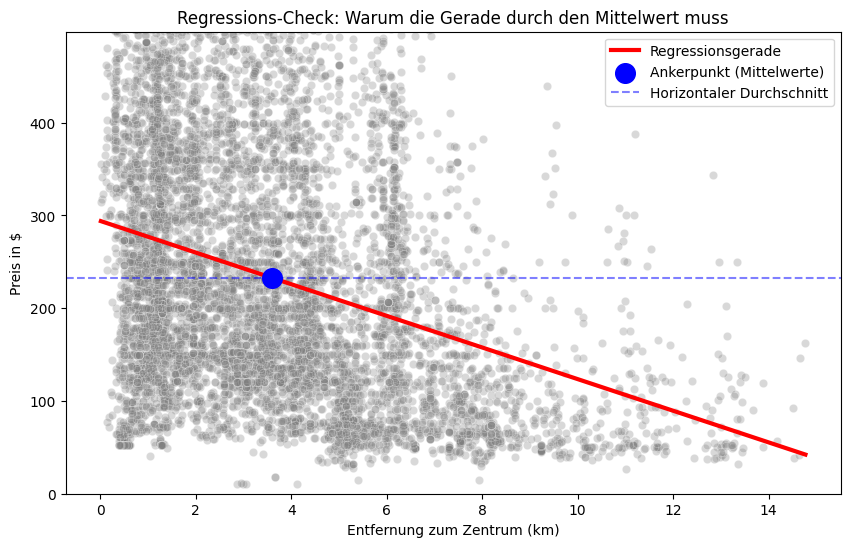

In [ ]:
plt.figure(figsize=(10, 6))

# Scatterplot der echten Daten (leicht transparent)
sns.scatterplot(data=df_manhattan, x='distance_to_center', y='price', alpha=0.3, color='gray')

# Die Regressionsgerade
x_range = pd.DataFrame(
    {'distance_to_center': [df_manhattan['distance_to_center'].min(), df_manhattan['distance_to_center'].max()]}
)
y_range = model_price.predict(x_range)
plt.plot(x_range, y_range, color='red', lw=3, label='Regressionsgerade')

# Der Ankerpunkt (Mittelwert von x und y)
plt.scatter(x_mean, y_mean, color='blue', s=200, zorder=5, label='Ankerpunkt (Mittelwerte)')

# Die horizontale Mittelwertlinie ("Null-Modell")
plt.axhline(y_mean, color='blue', linestyle='--', alpha=0.5, label='Horizontaler Durchschnitt')

plt.title('Regressions-Check: Warum die Gerade durch den Mittelwert muss')
plt.xlabel('Entfernung zum Zentrum (km)')
plt.ylabel('Preis in $')
plt.legend()
plt.ylim(0, df_manhattan['price'].quantile(0.95)) # Zoom auf 95% der Daten für bessere Sicht
plt.show()

In [41]:
residuen = y - model.predict(X)
print(f"Standardabweichung der Preise (sy): {y.std():.2f}")
print(f"Standardabweichung der Residuen:    {residuen.std():.2f}")

Standardabweichung der Preise (sy): 135.36
Standardabweichung der Residuen:    135.27


In [42]:
# R-Quadrat (Bestimmtheitsmaß) direkt vom Modell
r_squared = model.score(X, y)

# Anzahl der Beobachtungen (n) und Anzahl der Prädiktoren (p)
n = len(y)
p = X.shape[1] # Bei dir aktuell 1 (nur bedrooms)

# Adjusted R-Squared berechnen
adj_r_squared = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)

print(f"R² (Bestimmtheitsmaß):      {r_squared:.4f}")
print(f"Adjusted R²:               {adj_r_squared:.4f}")

R² (Bestimmtheitsmaß):      -2.8230
Adjusted R²:               -2.8235


### Neuer Durchlauf mit ln_price als Zielvariable

In [33]:
# 1. Daten vorbereiten (Filter auf Manhattan & Zeilen ohne NaN in distance_to_center)
df_manhattan = df[df['neighbourhood_group_cleansed'] == 'Manhattan'].dropna(subset=['distance_to_center', 'ln_price'])

# 2. Mittelwerte berechnen (x_quer und y_quer)
x_mean = df_manhattan['distance_to_center'].mean()
y_mean = df_manhattan['ln_price'].mean()
# 3. Lineare Regression berechnen
X = df_manhattan[['distance_to_center']]
y = df_manhattan['ln_price']
model_price = LinearRegression().fit(X, y)

b = model_price.coef_[0]      # Die Steigung
a = model_price.intercept_    # Der y-Achsenabschnitt

# 4. Die mathematische Prüfung: Ergibt a + b * x_mean wirklich y_mean?
y_pred_at_mean = a + (b * x_mean)

print(f"--- Ergebnisse für Manhattan ---")
print(f"Durchschnitt Entfernung zum Zentrum (x_quer): {x_mean:.2f}")
print(f"Durchschnitt ln_Preis (y_quer):        {y_mean:.2f} $")
print(f"---------------------------------")
print(f"Steigung (b):                     {b:.2f} % pro km weiter weg)")
print(f"y-Achsenabschnitt (a):             {a:.2f} $ (Basispreis)")
print(f"---------------------------------")
print(f"Check: a + b * x_quer =           {y_pred_at_mean:.2f} $")

--- Ergebnisse für Manhattan ---
Durchschnitt Entfernung zum Zentrum (x_quer): 3.60
Durchschnitt ln_Preis (y_quer):        5.26 $
---------------------------------
Steigung (b):                     -0.10 % pro km weiter weg)
y-Achsenabschnitt (a):             5.62 $ (Basispreis)
---------------------------------
Check: a + b * x_quer =           5.26 $


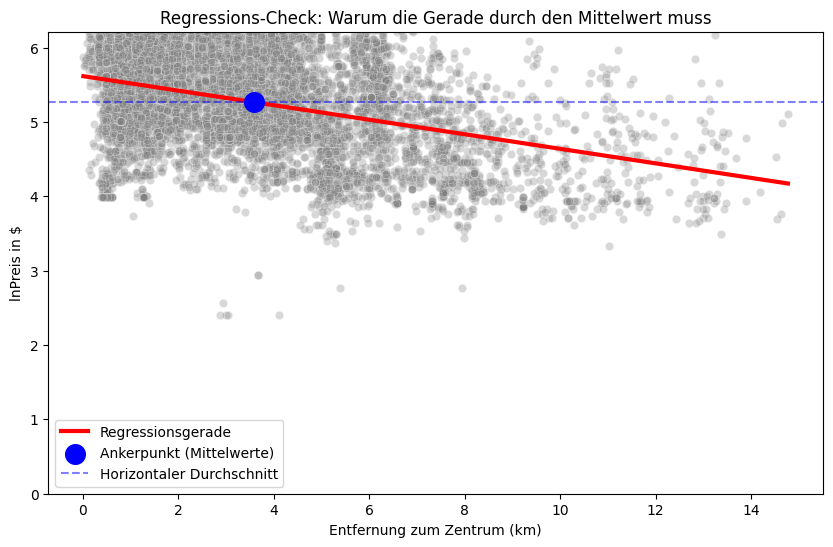

In [34]:
plt.figure(figsize=(10, 6))

# Scatterplot der echten Daten (leicht transparent)
sns.scatterplot(data=df_manhattan, x='distance_to_center', y='ln_price', alpha=0.3, color='gray')

# Die Regressionsgerade
x_range = pd.DataFrame(
    {'distance_to_center': [df_manhattan['distance_to_center'].min(), df_manhattan['distance_to_center'].max()]}
)
y_range = model.predict(x_range)
plt.plot(x_range, y_range, color='red', lw=3, label='Regressionsgerade')

# Der Ankerpunkt (Mittelwert von x und y)
plt.scatter(x_mean, y_mean, color='blue', s=200, zorder=5, label='Ankerpunkt (Mittelwerte)')

# Die horizontale Mittelwertlinie (dein "Null-Modell")
plt.axhline(y_mean, color='blue', linestyle='--', alpha=0.5, label='Horizontaler Durchschnitt')

plt.title('Regressions-Check: Warum die Gerade durch den Mittelwert muss')
plt.xlabel('Entfernung zum Zentrum (km)')
plt.ylabel('lnPreis in $')
plt.legend()
plt.ylim(0, df_manhattan['ln_price'].quantile(0.95)) # Zoom auf 95% der Daten für bessere Sicht
plt.show()

Beide Schaubilder in einem Plot darstellen

c:\Users\Annette\Data_Science\02_data-analytics\05_regression_projekt_airbnb\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Annette\Data_Science\02_data-analytics\05_regression_projekt_airbnb\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


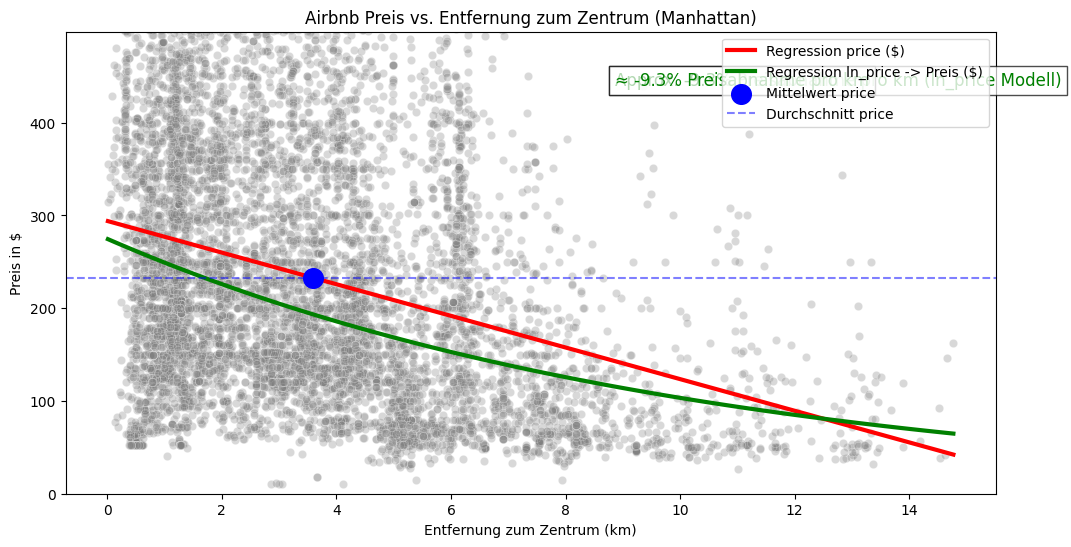

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# --- DataFrame df_manhattan ist schon vorbereitet ---
X = df_manhattan[['distance_to_center']]

# 1️⃣ Originalpreis-Modell
y_price = df_manhattan['price']
model_price = LinearRegression().fit(X, y_price)
x_mean = X['distance_to_center'].mean()
y_mean = y_price.mean()

# 2️⃣ ln_price-Modell
y_ln = df_manhattan['ln_price']
model_ln = LinearRegression().fit(X, y_ln)
b_ln = model_ln.coef_[0]
pct_per_km = (np.exp(b_ln)-1)*100  # %-Änderung pro km

# Steigung aus ln_price-Modell
b_ln = model_ln.coef_[0]                     # Steigung in ln(price)
pct_per_km = (np.exp(b_ln) - 1) * 100       # %-Abnahme pro km


# --- Plot ---
plt.figure(figsize=(12,6))

# Scatter
sns.scatterplot(x=X['distance_to_center'], y=y_price, alpha=0.3, color='gray')

# x-Werte für Linien
x_vals = np.linspace(X['distance_to_center'].min(), X['distance_to_center'].max(), 100).reshape(-1,1)

# Regressionsgerade price
y_vals_price = model_price.predict(x_vals)
plt.plot(x_vals.flatten(), y_vals_price, color='red', lw=3, label='Regression price ($)')

# Regressionsgerade ln_price -> zurück auf $ Skala
y_vals_ln = np.exp(model_ln.predict(x_vals))
plt.plot(x_vals.flatten(), y_vals_ln, color='green', lw=3, label='Regression ln_price -> Preis ($)')

# Mittelwertpunkte
plt.scatter(x_mean, y_mean, color='blue', s=200, zorder=5, label='Mittelwert price')

# Horizontaler Durchschnitt
plt.axhline(y_mean, color='blue', linestyle='--', alpha=0.5, label='Durchschnitt price')

# Annotation %-Abnahme
plt.text(
    X['distance_to_center'].max()*0.6,
    df_manhattan['price'].quantile(0.9),
    f"Approx. {pct_per_km:.1f}% Preisabnahme pro km (ln_price Modell)",
    color='green', fontsize=12, bbox=dict(facecolor='white', alpha=0.7)
)

plt.xlabel('Entfernung zum Zentrum (km)')
plt.ylabel('Preis in $')
plt.title('Airbnb Preis vs. Entfernung zum Zentrum (Manhattan)')
plt.legend()
plt.ylim(0, df_manhattan['price'].quantile(0.95))

plt.text(
    x=df_manhattan['distance_to_center'].max() * 0.6,
    y=df_manhattan['price'].quantile(0.9),
    s=f"≈ {pct_per_km:.1f}% Preisabnahme pro km",
    color='green',
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.7)
)


plt.show()


Mit Polynom 

c:\Users\Annette\Data_Science\02_data-analytics\05_regression_projekt_airbnb\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Annette\Data_Science\02_data-analytics\05_regression_projekt_airbnb\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Annette\Data_Science\02_data-analytics\05_regression_projekt_airbnb\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\Annette\Data_Science\02_data-analytics\05_regression_projekt_airbnb\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  w

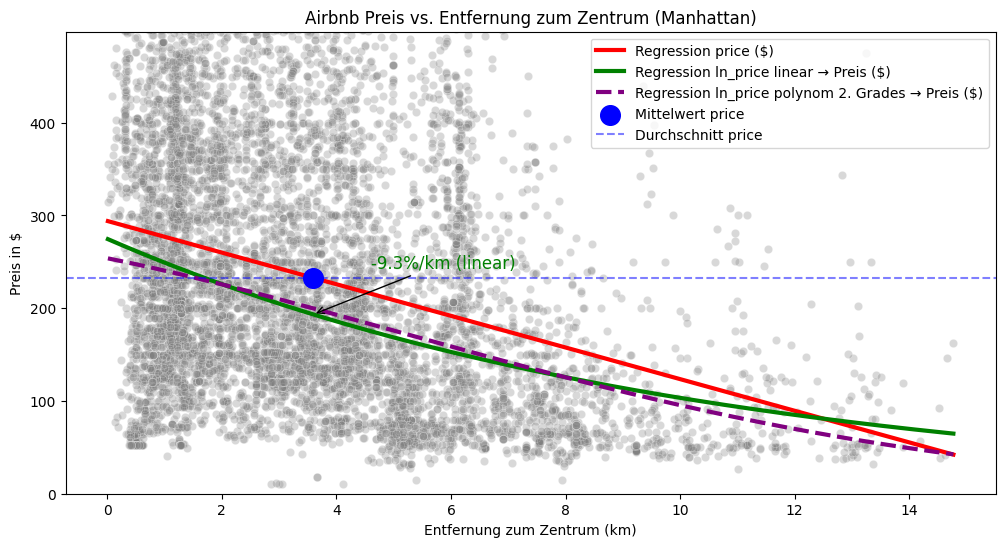

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# --- X & y vorbereiten ---
X = df_manhattan[['distance_to_center']]
y_price = df_manhattan['price']
y_ln = df_manhattan['ln_price']

# --- Lineares Modell ---
model_price = LinearRegression().fit(X, y_price)
model_ln = LinearRegression().fit(X, y_ln)

# --- Polynomial 2. Grades für ln_price ---
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
model_ln_poly = LinearRegression().fit(X_poly, y_ln)

# Mittelwerte
x_mean = X['distance_to_center'].mean()
y_mean = y_price.mean()

# %-Steigung lineares ln_price-Modell
b_ln = model_ln.coef_[0]
pct_per_km = (np.exp(b_ln) - 1) * 100  # negative Zahl = Abnahme

# x-Werte für Linien
x_vals = np.linspace(X['distance_to_center'].min(), X['distance_to_center'].max(), 200).reshape(-1,1)

# --- Linienwerte ---
y_vals_price = model_price.predict(x_vals)  # lineares price
y_vals_ln = np.exp(model_ln.predict(x_vals))  # lineares ln_price zurücktransformiert
y_vals_ln_poly = np.exp(model_ln_poly.predict(poly.transform(x_vals)))  # polynomiales ln_price

# --- Plot ---
plt.figure(figsize=(12,6))

# Scatter Originalpreise
sns.scatterplot(x=X['distance_to_center'], y=y_price, alpha=0.3, color='gray')

# Regressionslinien
plt.plot(x_vals.flatten(), y_vals_price, color='red', lw=3, label='Regression price ($)')
plt.plot(x_vals.flatten(), y_vals_ln, color='green', lw=3, label='Regression ln_price linear → Preis ($)')
plt.plot(x_vals.flatten(), y_vals_ln_poly, color='purple', lw=3, linestyle='--',
         label='Regression ln_price polynom 2. Grades → Preis ($)')

# Mittelwertpunkt
plt.scatter(x_mean, y_mean, color='blue', s=200, zorder=5, label='Mittelwert price')

# Horizontale Mittelwertlinie
plt.axhline(y_mean, color='blue', linestyle='--', alpha=0.5, label='Durchschnitt price')

# Annotation %-Abnahme lineares ln_price
plt.annotate(
    f"{pct_per_km:.1f}%/km (linear)",
    xy=(x_mean, np.exp(model_ln.predict([[x_mean]]))[0]),        # Punkt auf Linie
    xytext=(x_mean+1, np.exp(model_ln.predict([[x_mean]]))[0]+50),  # Textposition
    arrowprops=dict(facecolor='green', arrowstyle='->'),
    color='green',
    fontsize=12
)

# Achsen & Titel
plt.xlabel('Entfernung zum Zentrum (km)')
plt.ylabel('Preis in $')
plt.title('Airbnb Preis vs. Entfernung zum Zentrum (Manhattan)')

# Legend und Y-Limit (Zoom auf 95% der Daten)
plt.legend()
plt.ylim(0, df_manhattan['price'].quantile(0.95))

plt.show()


c:\Users\Annette\Data_Science\02_data-analytics\05_regression_projekt_airbnb\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Annette\Data_Science\02_data-analytics\05_regression_projekt_airbnb\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Annette\Data_Science\02_data-analytics\05_regression_projekt_airbnb\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\Annette\Data_Science\02_data-analytics\05_regression_projekt_airbnb\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  w

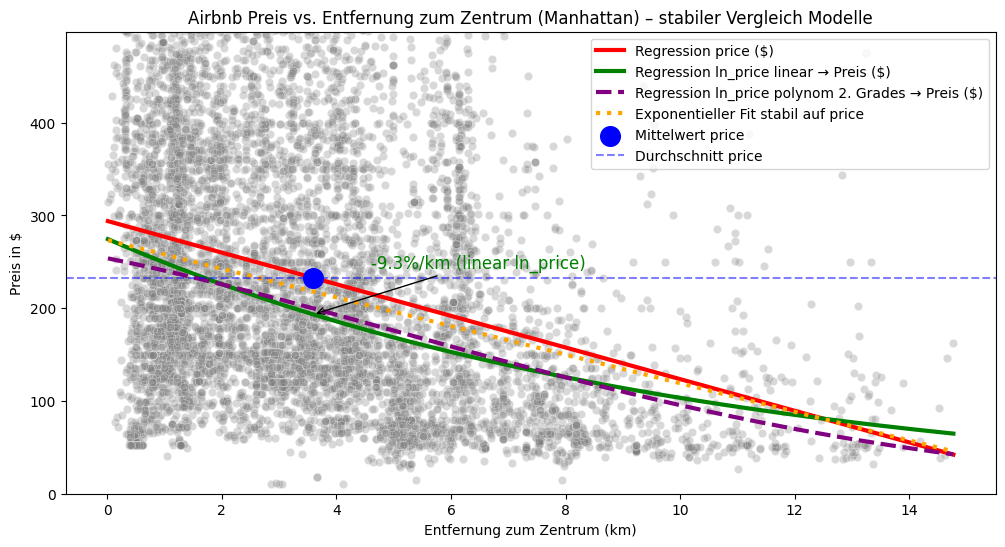

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from scipy.optimize import curve_fit

# --- X & y ---
X = df_manhattan[['distance_to_center']]
y_price = df_manhattan['price']
y_ln = df_manhattan['ln_price']

# --- Lineares Modell ---
model_price = LinearRegression().fit(X, y_price)
model_ln = LinearRegression().fit(X, y_ln)

# --- Polynomial 2. Grades für ln_price ---
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
model_ln_poly = LinearRegression().fit(X_poly, y_ln)

# --- Exponentieller Fit stabil ---
def exp_decay(x, A, k, C):
    return A * np.exp(-k * x) + C

# Ausreißer entfernen (oberes 5%-Quantil)
mask = y_price < y_price.quantile(0.95)
X_fit = X[mask]
y_fit = y_price[mask]

# Startwerte dynamisch
A_start = y_fit.max() - np.median(y_fit)
k_start = 0.1
C_start = y_fit.min()

popt, _ = curve_fit(exp_decay, X_fit['distance_to_center'], y_fit,
                    p0=[A_start, k_start, C_start],
                    maxfev=5000)

# Mittelwerte
x_mean = X['distance_to_center'].mean()
y_mean = y_price.mean()

# %-Steigung linear ln_price
b_ln = model_ln.coef_[0]
pct_per_km = (np.exp(b_ln) - 1) * 100

# x-Werte für Linien
x_vals = np.linspace(X['distance_to_center'].min(), X['distance_to_center'].max(), 200).reshape(-1,1)

# Linienwerte
y_vals_price = model_price.predict(x_vals)
y_vals_ln = np.exp(model_ln.predict(x_vals))
y_vals_ln_poly = np.exp(model_ln_poly.predict(poly.transform(x_vals)))
y_vals_exp = exp_decay(x_vals.flatten(), *popt)

# --- Plot ---
plt.figure(figsize=(12,6))

# Scatter
sns.scatterplot(x=X['distance_to_center'], y=y_price, alpha=0.3, color='gray')

# Regressionen
plt.plot(x_vals.flatten(), y_vals_price, color='red', lw=3, label='Regression price ($)')
plt.plot(x_vals.flatten(), y_vals_ln, color='green', lw=3, label='Regression ln_price linear → Preis ($)')
plt.plot(x_vals.flatten(), y_vals_ln_poly, color='purple', lw=3, linestyle='--',
         label='Regression ln_price polynom 2. Grades → Preis ($)')
plt.plot(x_vals.flatten(), y_vals_exp, color='orange', lw=3, linestyle=':', label='Exponentieller Fit stabil auf price')

# Mittelwertpunkt + horizontale Linie
plt.scatter(x_mean, y_mean, color='blue', s=200, zorder=5, label='Mittelwert price')
plt.axhline(y_mean, color='blue', linestyle='--', alpha=0.5, label='Durchschnitt price')

# Annotation %-Steigung linear ln_price
plt.annotate(
    f"{pct_per_km:.1f}%/km (linear ln_price)",
    xy=(x_mean, np.exp(model_ln.predict([[x_mean]]))[0]),
    xytext=(x_mean+1, np.exp(model_ln.predict([[x_mean]]))[0]+50),
    arrowprops=dict(facecolor='green', arrowstyle='->'),
    color='green',
    fontsize=12
)

# Achsen, Titel, Legend
plt.xlabel('Entfernung zum Zentrum (km)')
plt.ylabel('Preis in $')
plt.title('Airbnb Preis vs. Entfernung zum Zentrum (Manhattan) – stabiler Vergleich Modelle')
plt.legend()
plt.ylim(0, df_manhattan['price'].quantile(0.95))

plt.show()


| Situation                 | Transformation  | Rücktransformation     |
|----------------------------|----------------|----------------------|
| Alle Preise > 0            | ln(price)       | exp(pred)            |
| Preise könnten 0 sein      | ln(price + 1)   | exp(pred) - 1        |


In [52]:
import numpy as np

# --- Situation 1: Alle Preise > 0 ---
price = 200
ln_price = np.log(price)        # Transformation
price_back = np.exp(ln_price)   # Rücktransformation
print(price_back)               # Ausgabe: 200

# --- Situation 2: Preise könnten 0 sein ---
price_zero = 0
ln_price1 = np.log(price_zero + 1)       # Transformation
price_back1 = np.exp(ln_price1) - 1      # Rücktransformation
print(price_back1)                        # Ausgabe: 0


199.99999999999991
0.0


### Bezug zur Draft Analysis

Am Ende meines Workflows habe ich:

- ein **finales Modell** (z. B. `model_ln`)
- trainiert auf **`ln_price`**
- evaluiert auf dem **Testset (`x_test`, `y_test`)**

Ab diesem Punkt beginnt die **inhaltliche Interpretation** des Modells.  
Meine nächsten Ziele sind:

1. die **Koeffizienten des Modells verstehen**
2. sie in **verständlich formulierte Aussagen** übersetzen
3. darauf aufbauend eine **Gradio-App** entwickeln, die auch für Nicht-Data-Scientists sinnvoll nutzbar ist

Damit wird aus dem reinen Modell ein **erklärbares, anwendbares Vorhersagesystem**.


#### Interpretation der Koeffizienten bei `ln(price)`

Das Modell lautet:

$$
\ln(\text{price}) = a + b_1 x_1 + b_2 x_2 + \cdots
$$

#### Rücktransformation in den Preisraum

Durch Anwenden der Exponentialfunktion erhält man:

$$
\text{price} = e^{a} \cdot e^{b_1 x_1} \cdot e^{b_2 x_2} \cdot \cdots
$$

Damit wirkt jeder Koeffizient **multiplikativ** auf den Preis.

---

#### Zentrale Interpretationsregel

Für jedes Feature \( x \) mit Koeffizient \( b \) gilt:

$$
\text{Pro Erhöhung von } x \text{ um 1 Einheit ändert sich der Preis um}
$$

$$
(e^{b} - 1) \cdot 100\%
$$

#### Bedeutung in Worten

> Eine Erhöhung von \( x \) um 1 Einheit führt zu einer prozentualen Preisänderung von  
> \( (e^{b} - 1) \cdot 100\% \).

### Beispiel

Angenommen der Koeffizient ist

$$
b = -0.18
$$

Dann ergibt sich:

$$
(e^{-0.18} - 1) \cdot 100\% \approx -16.5\%
$$

**Interpretation:**

> Erhöht sich \( x \) um 1 Einheit, sinkt der erwartete Preis um ca. **16.5 %**.


In [55]:
b = -0.083
pct = (np.exp(b) - 1) * 100
print(f"Prozentuale Abnahme pro km: {pct:.2f}%")



Prozentuale Abnahme pro km: -7.96%


Wenn die Entfernung zum Zentrum um 1 km steigt, sinkt der erwartete Airbnb-Preis um ca. 8 % — bei sonst gleichen Bedingungen.

Fit best model on X_train
→ tune hyperparameters (optional)
→ evaluate once on X_test
→ freeze model
→ interpret coefficients
→ build Gradio app


In [57]:
coef_table = pd.DataFrame({
    "feature": X.columns,
    "b": model_ln.coef_,
})

coef_table["pct_effect_per_unit"] = (np.exp(coef_table["b"]) - 1) * 100

print(coef_table)


              feature       b  pct_effect_per_unit
0  distance_to_center -0.0978            -9.316963


Für draft-analysis: 



In [58]:
import pandas as pd
import numpy as np

# Beispiel: Modell mit mehreren Features
features = X.columns
coefs = model_ln.coef_

result = pd.DataFrame({
    "feature": features,
    "b": coefs,
    "pct_effect_per_unit": (np.exp(coefs) - 1) * 100
})

# Schön runden
result["b"] = result["b"].round(3)
result["pct_effect_per_unit"] = result["pct_effect_per_unit"].round(2)

result


,feature,b,pct_effect_per_unit
0,distance_to_center,-0.098,-9.32


#### Umrechnung von Koeffizienten bei `ln(price)`-Modellen

$$
\text{Prozent-Effekt} = (e^{b} - 1) \cdot 100
$$

#### Beispiel

Für deinen Koeffizienten

$$
b = -0.098
$$

ergibt sich:

$$
(e^{-0.098} - 1) \cdot 100 \approx -9.32\%
$$

#### ❌ Falsche (aber oft gemachte) Abkürzung

$$
-0.098 \times 100
$$

Diese Rechnung ist **nicht korrekt** und darf **nicht** zur Interpretation verwendet werden.

#### Merksatz

Bei logarithmierten Zielvariablen sind Regressionskoeffizienten **niemals direkt Prozent**.  
Die Prozentwirkung ergibt sich **immer** aus:

$$
(e^{b} - 1) \cdot 100
$$
